[Linux | Windows]

[env: optonpx]

In [1]:
# Visualize an Open Ephys Neuropixels probe-survey JSON.
#
# A probe survey cycles through every bank on every shank and measures a
# per-electrode AP-band peak-to-peak amplitude — a signal-quality proxy used
# to decide which bank to select on each shank before recording. This
# notebook only visualizes the survey; the actual channel map is built with
# a separate tool.

In [2]:
# path and params
from pathlib import Path

survey_json_path = Path("./testdata/neuropixels_survey_2026-08-31_15-36-28.json")
is_save = True
save_dir = Path("/mnt/c/users/jeff/downloads/output_optonpx")

if survey_json_path.exists():
    print("Survey file exists.")
if is_save:
    if save_dir.exists():
        print("Output directory already exists.")
    else:
        print("Output directory does not exist yet.")

METRIC = "peak_to_peak"

Survey file exists.
Output directory already exists.


In [3]:
import sys
import json
import matplotlib.pyplot as plt
sys.path.append("..")

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

with open(survey_json_path, "r", encoding="utf-8") as f:
    survey = json.load(f)

print(f"Survey file      : {survey_json_path.name}")
print(f"Generated at     : {survey['generated_at']}")
print(f"Seconds / config : {survey['seconds_per_configuration']}")
print(f"Probes           : {survey['probe_count']}")
for p in survey["probes"]:
    print(f"  {p['name']}  serial={p['serial_number']}  "
          f"shanks={p['shanks_surveyed']}  banks={p['banks_surveyed']}  "
          f"electrodes={len(p['electrodes'])}")

Survey file      : neuropixels_survey_2026-08-31_15-36-28.json
Generated at     : 2026-08-31T15:36:28.148-07:00
Seconds / config : 10.0
Probes           : 2
  ProbeA  serial=25048419171  shanks=[0, 1, 2, 3]  banks=['A', 'B', 'C', 'D']  electrodes=5120
  ProbeB  serial=25048411301  shanks=[0, 1, 2, 3]  banks=['A', 'B', 'C', 'D']  electrodes=5120


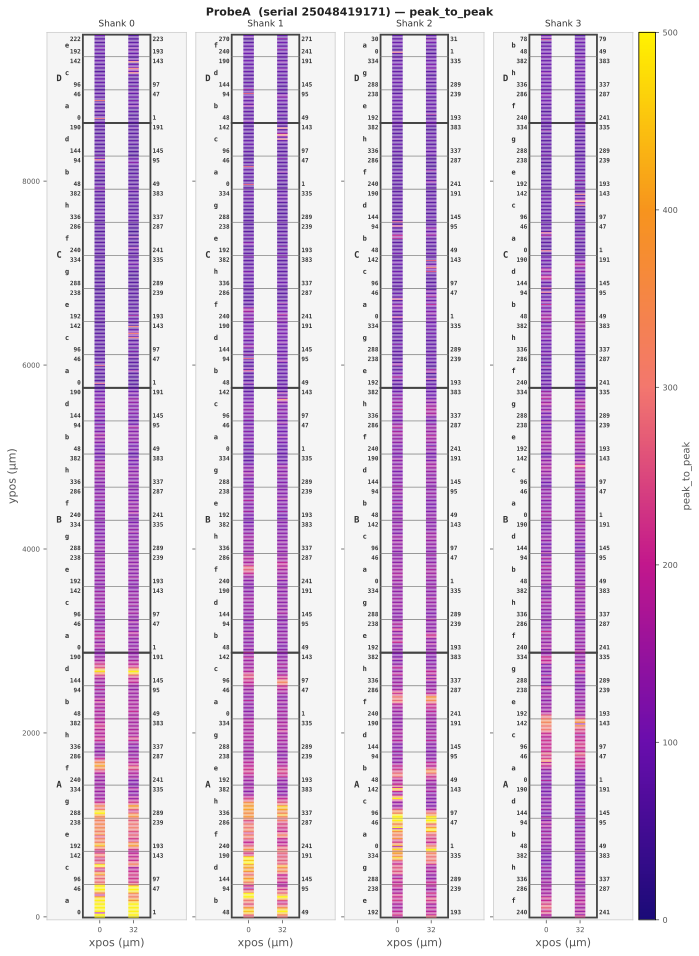

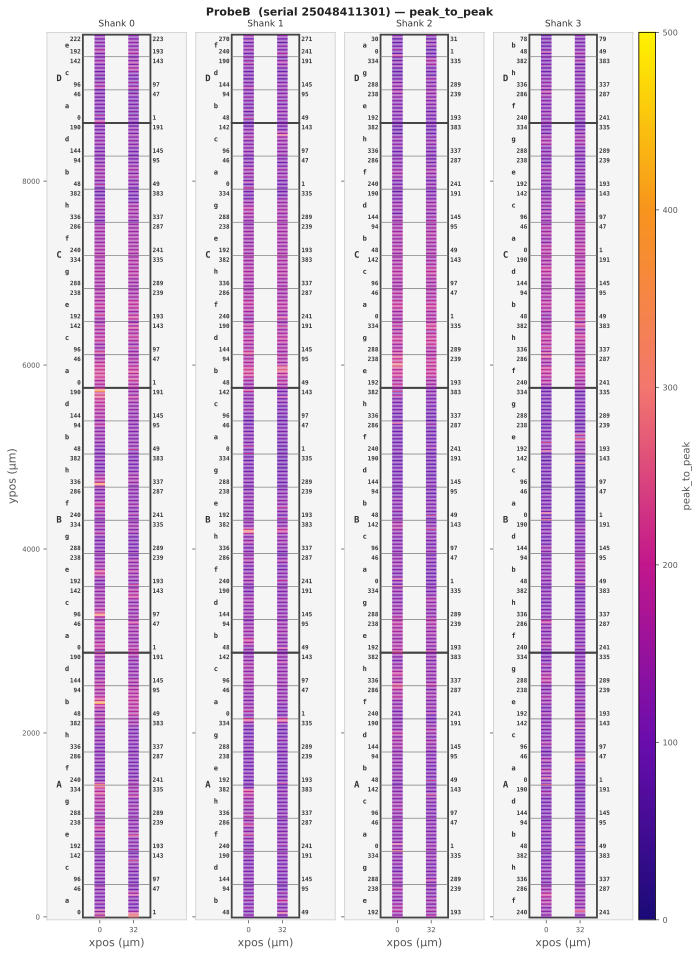

Figures saved to: /mnt/c/users/jeff/downloads/output_optonpx


In [4]:
from src import plot_probe_survey

# spatial heatmap, one figure per probe
save_dir.mkdir(parents=True, exist_ok=True)

for probe in survey["probes"]:
    electrodes = probe["electrodes"]
    label = f"{probe['name']}  (serial {probe['serial_number']})"

    fig_map = plot_probe_survey(electrodes, metric=METRIC, title=f"{label} — {METRIC}")
    plt.show()
    if is_save:
        fig_map.savefig(save_dir / f"{probe['name']}_survey_{METRIC}_map.png",
                        bbox_inches="tight", dpi=300)

print(f"Figures saved to: {save_dir}")

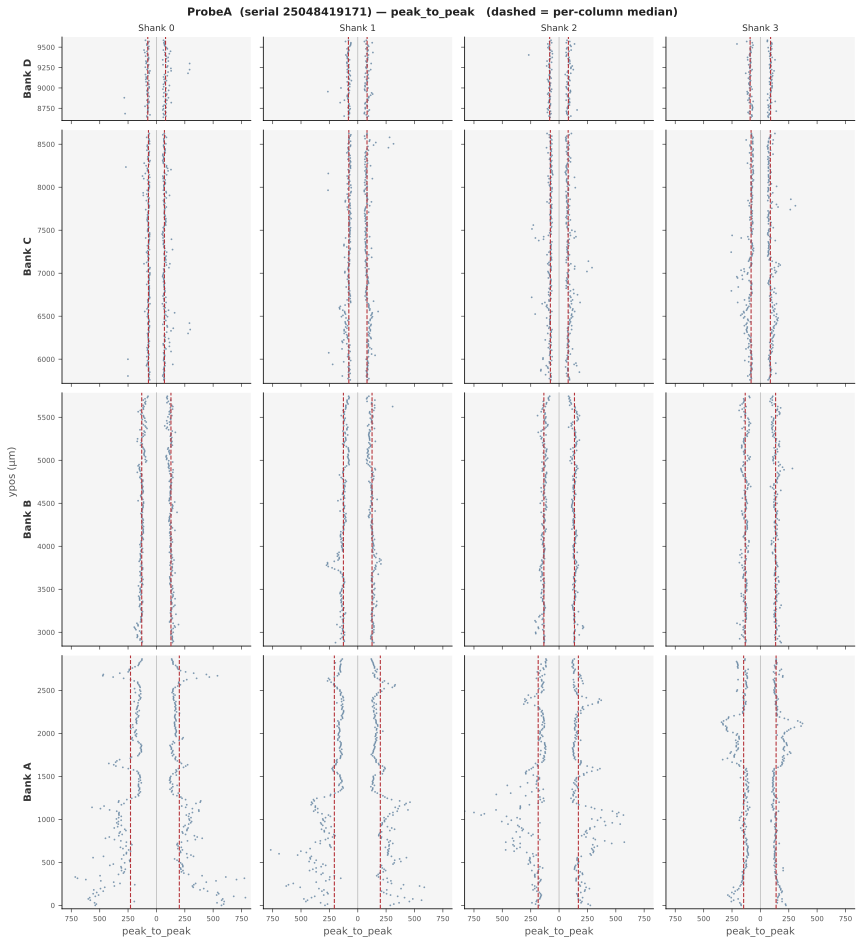

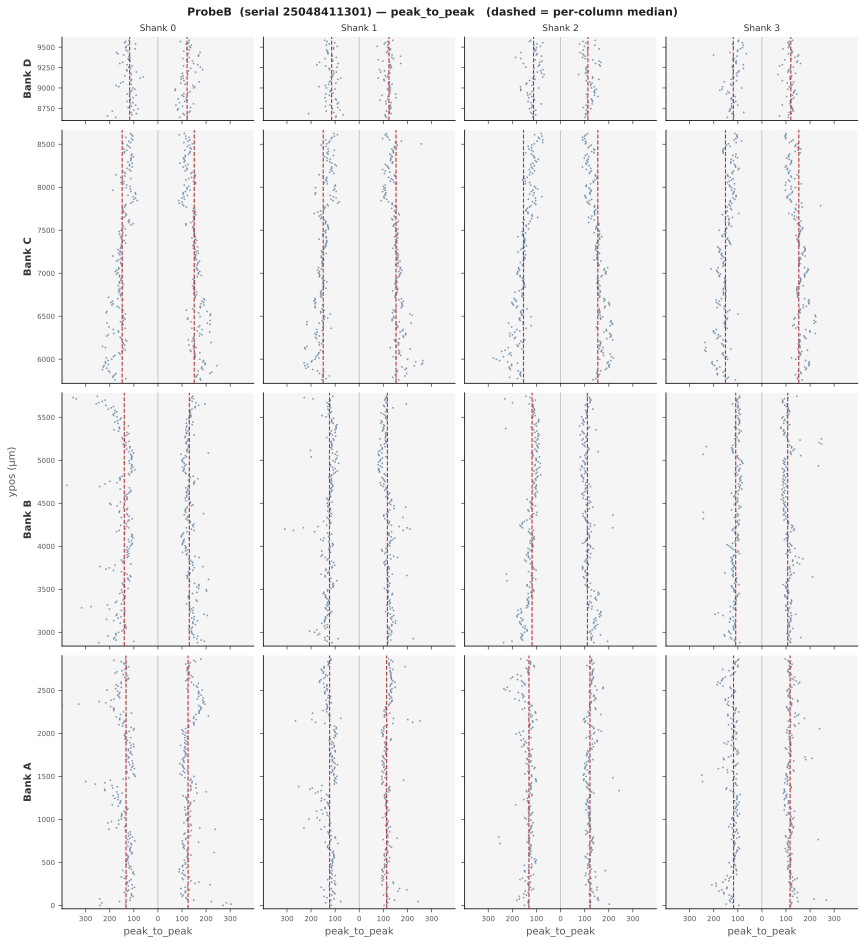

In [5]:
from src import plot_probe_survey_bank_summary

# per-(shank, bank) grid of the metric vs electrode depth — a quantitative
# complement to the spatial heatmap for choosing which bank to record.
# columns = shanks, rows = banks (A bottom -> D top); within a cell the two
# electrode columns form a mirrored scatter about 0, dashed line = per-column
# median (pass central="mean" to switch)
for probe in survey["probes"]:
    electrodes = probe["electrodes"]
    label = f"{probe['name']}  (serial {probe['serial_number']})"

    fig_bank = plot_probe_survey_bank_summary(electrodes, metric=METRIC, title=f"{label} — {METRIC}")
    plt.show()
    if is_save:
        fig_bank.savefig(save_dir / f"{probe['name']}_survey_{METRIC}_bank_summary.png",
                         bbox_inches="tight", dpi=300)


In [6]:
# interactive version: hover an electrode to see its shank/bank/row/column/
# global_index and value (a survey has no recorded "channel" yet — this is
# the identifying info to reference when building the real channel map).
# Toolbar: pan (drag = pan y, mouse wheel = zoom y), reset, save; x stays fixed.
# One probe per cell -- keeps each Bokeh document isolated.
from bokeh.plotting import show as bokeh_show
from src import plot_probe_survey_interactive

probe = survey["probes"][0]
label = f"{probe['name']}  (serial {probe['serial_number']})"
bokeh_show(plot_probe_survey_interactive(probe["electrodes"], metric=METRIC,
                                         title=f"{label} — {METRIC}"))


In [7]:
probe = survey["probes"][1]
label = f"{probe['name']}  (serial {probe['serial_number']})"
bokeh_show(plot_probe_survey_interactive(probe["electrodes"], metric=METRIC,
                                         title=f"{label} — {METRIC}"))
